# 03 - Treinamento e Avaliação dos Modelos

Este notebook treina e compara modelos de Machine Learning para prever a coluna `vibe` das músicas.

Nesta versão, o treinamento utiliza somente as 7 features oficiais:

- `danceability`
- `energy`
- `valence`
- `acousticness`
- `instrumentalness`
- `speechiness`
- `tempo`

Essas variáveis foram escolhidas porque podem ser representadas a partir das respostas do usuário no aplicativo e também são as principais características musicais usadas no projeto.

Entrada esperada:

```text
data/dataset_treino_balanceado.csv
```

Modelos avaliados:

- Random Forest
- Decision Tree
- KNN
- Logistic Regression
- Naive Bayes


## 1. Importação das bibliotecas

In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

## 2. Carregamento da base balanceada

In [2]:
df = pd.read_csv("../data/dataset_treino_balanceado.csv")

df.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,vibe
0,59,219240,False,0.833,0.639,5,-6.964,1,0.0676,0.152000,0.000000,0.1010,0.4480,102.989,4,party
1,30,579925,True,0.595,0.806,2,-5.732,1,0.9370,0.729000,0.000000,0.8730,0.4490,82.933,4,party
2,80,205090,True,0.731,0.573,4,-10.059,0,0.0544,0.401000,0.000052,0.1130,0.1450,109.928,4,party
3,7,407680,False,0.806,0.576,1,-12.158,0,0.0512,0.000163,0.862000,0.0927,0.0518,122.970,4,party
4,0,191533,False,0.863,0.624,3,-5.637,1,0.0375,0.540000,0.000008,0.0300,0.9580,105.490,4,party


In [3]:
df["vibe"].value_counts()

vibe
party       3000
relax       3000
workout     3000
romantic    3000
focus       3000
chill        590
Name: count, dtype: int64

## 3. Separação entre variáveis de entrada e variável alvo

A variável alvo é:

```text
vibe
```

Para este treinamento foram utilizadas apenas as 7 features compatíveis com a integração do backend:

```text
danceability, energy, valence, acousticness, instrumentalness, speechiness, tempo
```

Essas variáveis são suficientes para representar características musicais relacionadas ao humor, energia, intensidade, ritmo e preferência por músicas instrumentais ou vocais.


In [4]:
FEATURES = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "tempo"
]

TARGET = "vibe"

X = df[FEATURES]
y = df[TARGET]

print("Variáveis usadas no treinamento:")
print(X.columns.tolist())

print("\nFormato de X:", X.shape)
print("Formato de y:", y.shape)

X.head()

Variáveis usadas no treinamento:
['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'speechiness', 'tempo']

Formato de X: (15590, 7)
Formato de y: (15590,)


,danceability,energy,valence,acousticness,instrumentalness,speechiness,tempo
0,0.833,0.639,0.4480,0.152000,0.000000,0.0676,102.989
1,0.595,0.806,0.4490,0.729000,0.000000,0.9370,82.933
2,0.731,0.573,0.1450,0.401000,0.000052,0.0544,109.928
3,0.806,0.576,0.0518,0.000163,0.862000,0.0512,122.970
4,0.863,0.624,0.9580,0.540000,0.000008,0.0375,105.490


## 4. Divisão entre treino e teste

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (12472, 7)
Teste: (3118, 7)


## 5. Normalização dos dados

A normalização foi aplicada para padronizar as escalas das variáveis numéricas antes do treinamento.

Mesmo que a maioria das features varie entre 0 e 1, a variável `tempo` possui escala diferente, pois representa BPM. Por isso, o uso do `StandardScaler` é importante para modelos sensíveis à escala, como KNN e Logistic Regression.


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Treinamento dos modelos

In [7]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB()
}

resultados = []

for nome, modelo in models.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-score": f1_score(y_test, y_pred, average="weighted")
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.949647,0.950568,0.949647,0.949514
1,Decision Tree,0.905709,0.905788,0.905709,0.905639
2,KNN,0.915651,0.917901,0.915651,0.915661
3,Logistic Regression,0.982360,0.982572,0.982360,0.982337
4,Naive Bayes,0.824246,0.844285,0.824246,0.822929


## 7. Salvando a comparação dos modelos

In [8]:
df_resultados.to_csv("../resultados/comparacao_modelos.csv", index=False)

print("Arquivo salvo em: resultados/comparacao_modelos.csv")

Arquivo salvo em: resultados/comparacao_modelos.csv


## 8. Melhor modelo

Após a comparação das métricas, o melhor modelo é selecionado automaticamente com base na maior acurácia.

Esse será o modelo salvo para futura integração com o backend.


In [9]:
melhor_modelo_nome = df_resultados.sort_values("Accuracy", ascending=False).iloc[0]["Modelo"]
melhor_modelo_nome

'Logistic Regression'

In [10]:
melhor_modelo = models[melhor_modelo_nome]

y_pred_best = melhor_modelo.predict(X_test_scaled)

print("Melhor modelo:", melhor_modelo_nome)
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_best))

Melhor modelo: Logistic Regression

Relatório de classificação:
              precision    recall  f1-score   support

       chill       0.96      0.93      0.95       118
       focus       0.98      0.99      0.99       600
       party       0.98      0.99      0.98       600
       relax       0.99      0.96      0.98       600
    romantic       0.97      1.00      0.98       600
     workout       1.00      0.98      0.99       600

    accuracy                           0.98      3118
   macro avg       0.98      0.98      0.98      3118
weighted avg       0.98      0.98      0.98      3118



## 9. Matriz de confusão do melhor modelo

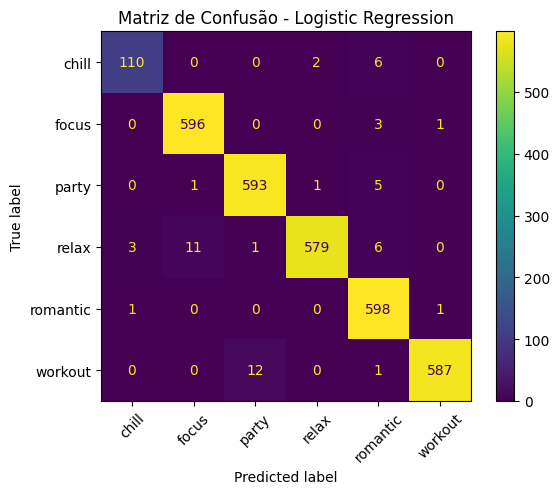

In [11]:
cm = confusion_matrix(y_test, y_pred_best, labels=melhor_modelo.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=melhor_modelo.classes_
)

disp.plot(xticks_rotation=45)
plt.title(f"Matriz de Confusão - {melhor_modelo_nome}")
plt.show()

## 10. Importância das variáveis

Para interpretar quais atributos musicais mais influenciam a classificação, será treinado um modelo Random Forest e analisada a importância das variáveis.

In [12]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

importancias = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": rf.feature_importances_
})

importancias = importancias.sort_values("Importancia", ascending=False)
importancias

,Variavel,Importancia
3,acousticness,0.195205
1,energy,0.186234
4,instrumentalness,0.181995
2,valence,0.174793
0,danceability,0.136217
6,tempo,0.091747
5,speechiness,0.033809


In [13]:
importancias.to_csv("../resultados/importancia_variaveis.csv", index=False)

print("Arquivo salvo em: resultados/importancia_variaveis.csv")

Arquivo salvo em: resultados/importancia_variaveis.csv


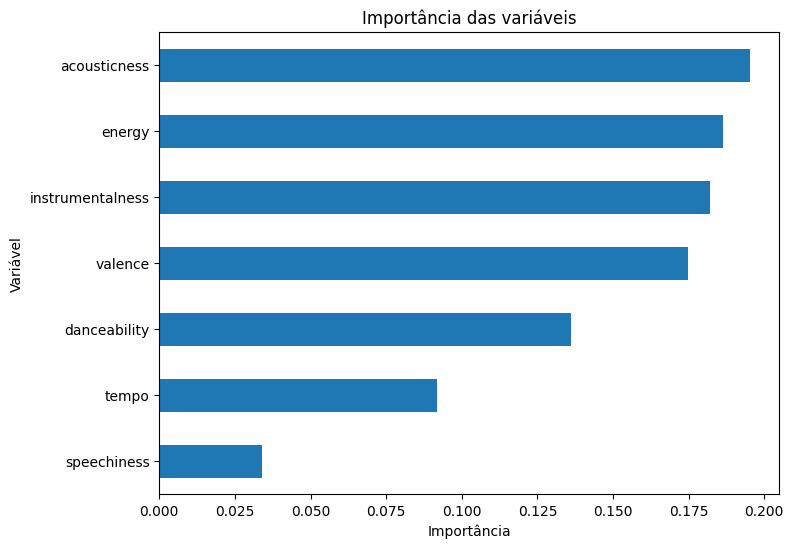

In [14]:
importancias.sort_values("Importancia").plot.barh(
    x="Variavel",
    y="Importancia",
    figsize=(8, 6),
    legend=False
)

plt.title("Importância das variáveis")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()

## 11. Salvamento do modelo para integração

Após a escolha do melhor modelo, serão salvos três arquivos na pasta `modelos/`:

- `model.pkl`: modelo treinado;
- `scaler.pkl`: normalizador usado no treinamento;
- `features.pkl`: lista das 7 features esperadas pelo modelo.

Esses arquivos permitem que o backend ou uma futura API de ML utilize exatamente o mesmo padrão de entrada usado durante o treinamento.


In [ ]:
os.makedirs("../modelos", exist_ok=True)

joblib.dump(melhor_modelo, "../modelos/model.pkl")
joblib.dump(scaler, "../modelos/scaler.pkl")
joblib.dump(FEATURES, "../modelos/features.pkl")

print("Arquivos salvos:")
print("- ../modelos/model.pkl")
print("- ../modelos/scaler.pkl")
print("- ../modelos/features.pkl")

Arquivos salvos:
- modelos/model.pkl
- modelos/scaler.pkl
- modelos/features.pkl


## 12. Teste manual de predição

A célula abaixo simula uma entrada futura do backend.

O backend deverá transformar as respostas do usuário em valores equivalentes às 7 features utilizadas pelo modelo.


In [17]:
entrada_exemplo = {
    "danceability": 0.80,
    "energy": 0.90,
    "valence": 0.75,
    "acousticness": 0.10,
    "instrumentalness": 0.05,
    "speechiness": 0.05,
    "tempo": 140
}

entrada_df = pd.DataFrame([entrada_exemplo])
entrada_df = entrada_df[FEATURES]

entrada_scaled = scaler.transform(entrada_df)

vibe_prevista = melhor_modelo.predict(entrada_scaled)[0]

print("Entrada simulada:")
print(entrada_exemplo)

print("\nVibe prevista:")
print(vibe_prevista)

Entrada simulada:
{'danceability': 0.8, 'energy': 0.9, 'valence': 0.75, 'acousticness': 0.1, 'instrumentalness': 0.05, 'speechiness': 0.05, 'tempo': 140}

Vibe prevista:
workout


## 13. Conclusão

Foram treinados e comparados cinco modelos de Machine Learning para classificação da vibe musical usando apenas as 7 features definidas como padrão de integração com o backend.

As métricas utilizadas foram:

- Accuracy;
- Precision;
- Recall;
- F1-score.

O melhor modelo foi selecionado automaticamente com base na acurácia e analisado por meio de relatório de classificação e matriz de confusão.

Também foi realizada a análise de importância das variáveis com Random Forest, indicando quais atributos musicais mais influenciam a classificação das vibes.

Por fim, foram salvos os artefatos necessários para futura integração:

- `modelos/model.pkl`;
- `modelos/scaler.pkl`;
- `modelos/features.pkl`.

Dessa forma, o modelo fica preparado para receber entradas no padrão definido pelo projeto e prever a `vibe` correspondente.
